# Surrogate Impact on Quantum Circuit Synthesis with Evolutionary Algorithms

## Set up Dependencies

In [40]:
import json
import numpy as np
import os
from pprint import pprint
import scipy
from statistics import mean, stdev
from typing import List, Dict, Callable


In [41]:
from tqdm.notebook import tqdm

In [42]:
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 100 # TODO: Change DPI before submitting paper.

In [43]:
import pandas as pd

## Util Functions

In [44]:
def load_json(path: str) -> Dict:
    with open(path, "r") as json_file:
        return json.load(json_file)

In [45]:
def printb(text: str) -> None:
    print("\033[1m" + text + "\033[0m")

In [46]:
from dataclasses import dataclass


@dataclass
class Experiment:
    model: str
    qubit_num: int
    gate_count: int

    parent_count: int
    offspring_count: int
    max_evaluations: int
    evaluate_every: int

    source_paths: List[str]
    seeds: List[int]

    tag: str
    data_per_seed: List[pd.DataFrame]
    data_by_generation: pd.DataFrame
    data_by_timestamp: pd.DataFrame
    data_by_evaluations: pd.DataFrame

    def __hash__(self) -> str:
        key = f"{self.qubit_num}_{self.gate_count}_{self.model}_"
        key += f"{self.parent_count}_{self.offspring_count}_"
        key += f"{self.max_evaluations}_{self.evaluate_every}"
        # key += f"{self.tag}t"
        return hash(key)

    def __eq__(self, value: "Experiment"):
        return self.__hash__() == value.__hash__()

    @property
    def config(self):
        return {
            "model": self.model,
            "qubit_num": self.qubit_num,
            "gate_count": self.gate_count,
            "parent_count": self.parent_count,
            "offspring_count": self.offspring_count,
            "max_evaluations": self.max_evaluations,
            "tag": self.tag,
            "evaluate_every": self.evaluate_every,
            "seeds": sorted(self.seeds)
        }

In [47]:
def filter_experiments(experiments: List[Experiment], filter_params: Dict, sort_by: str = "qubit_num") -> List[Experiment]:

    filtered_experiments: List[Experiment] = []
    for experiment in experiments:

        for key, value in filter_params.items():
            
            if experiment.config[key] != value:
                break 

        else:
            filtered_experiments.append(experiment)                 


    filtered_experiments.sort(key=lambda item: item.config[sort_by])
    return filtered_experiments

In [48]:
def sort_by_model(experiments: List[Experiment]) -> None:
    experiment_models = [
        experiment.model for experiment in experiments]

    if None in experiment_models:
        no_model_index = experiment_models.index(None)
        no_model_experiment = experiments.pop(no_model_index)

    experiments.sort(key=lambda experiment: experiment.model)

    if None in experiment_models:
        experiments.insert(0, no_model_experiment)

In [ ]:
def load_experiments(results_dir: str = "results", min_evaluations: int = None, apply_timestamp_merging: bool = True, apply_evaluations_merging: bool = True) -> List[Experiment]:
    experiments: Dict[str, Experiment] = {}

    for file_name in os.listdir(results_dir):
        if not file_name.endswith("_config.json"):
            continue

        config_path = f"{results_dir}/{file_name}"
        config = load_json(config_path)

        logging_prefix: str = config["params"]["logging_prefix"]

        data_path = logging_prefix + "_results.csv"

        experiment_data = pd.read_csv(data_path, delimiter=";")
        for column in experiment_data.columns:
            experiment_data = experiment_data.rename(columns={
                column: column.strip().replace(" ", "_")
            })
        enhance_data(experiment_data)

        experiment = Experiment(
            model=config["params"]["surrogate"]["type"] if "type" in config["params"]["surrogate"] else None,
            qubit_num=config["params"]["ea"]["qubit_num"],
            gate_count=config["params"]["ea"]["gate_count"],

            parent_count=config["params"]["ea"]["parent_count"],
            offspring_count=config["params"]["ea"]["offspring_count"],
            max_evaluations=config["params"]["ea"]["max_evaluations"],
            evaluate_every=config["params"]["ea"]["evaluate_every"],

            tag=config["params"]["tag"],

            source_paths=[
                config_path
            ],

            seeds=[
                config["params"]["seed"]
            ],

            data_per_seed=[experiment_data],
            data_by_generation=None,
            data_by_timestamp=None,
            data_by_evaluations=None,
        )

        if experiment in experiments and experiment.seeds[0] in experiments[experiment].seeds:
            print(
                f"Excluding data of {experiment.source_paths[0]} due to seed duplication.")
            
        elif experiment in experiments:
            experiments[experiment].source_paths.append(
                experiment.source_paths[0])
            experiments[experiment].seeds.append(experiment.seeds[0])
            experiments[experiment].data_per_seed.append(
                experiment.data_per_seed[0])
            
        else:
            experiments[experiment] = experiment

    experiments: List[Experiment] = list(experiments.values())

    for experiment in experiments:
        data_dfs = experiment.data_per_seed

        if min_evaluations is None:
            min_evaluation_threshold = experiment.max_evaluations
        else:
            min_evaluation_threshold = min_evaluations

        entries_to_pop = []
        for i, seed_df in enumerate(data_dfs):
            if max(seed_df["cum_explicit_evaluations"]) < min_evaluation_threshold:
                entries_to_pop.append(i)

        for entry_to_pop in reversed(entries_to_pop):
            print(
                f"Excluding fitness of {experiment.source_paths[entry_to_pop]}.")

            experiment.source_paths.pop(entry_to_pop)
            experiment.seeds.pop(entry_to_pop)
            experiment.data_per_seed.pop(entry_to_pop)

    experiments = [
        experiment for experiment in experiments if len(experiment.seeds) > 1
    ]

    for experiment in tqdm(experiments, desc="Experiments"):

        experiment.data_by_generation = merge_by_generation(
            experiment.data_per_seed)

        if apply_timestamp_merging:
            experiment.data_by_timestamp = merge_by_timestamp(
                experiment.data_per_seed)

        if apply_evaluations_merging:
            experiment.data_by_evaluations = merge_by_evaluations(
                experiment.data_per_seed)

    return experiments

In [50]:
def enhance_data(df: pd.DataFrame):
    df["cum_duration"] = df["total_duration"].cumsum()

In [ ]:
def merge_by_generation(dfs: List[pd.DataFrame]) -> pd.DataFrame:
    min_generations = min([
        max(df["generation"]) for df in dfs
    ])

    for i in range(len(dfs)):
        dfs[i] = dfs[i][dfs[i]["generation"] <= min_generations]

    total_df = pd.concat(dfs)

    grouped_fitness = total_df.groupby("generation")["fitness_best"]
    mean_best_fitness = grouped_fitness.mean()
    median_best_fitness = grouped_fitness.median()
    stdev_best_fitness = grouped_fitness.std()

    grouped_ea_duration = total_df.groupby("generation")["ea_duration"]
    mean_ea_duration = grouped_ea_duration.mean()
    median_ea_duration = grouped_ea_duration.median()
    stdev_ea_duration = grouped_ea_duration.std()

    grouped_eval_duration = total_df.groupby("generation")["eval_duration"]
    mean_eval_duration = grouped_eval_duration.mean()
    median_eval_duration = grouped_eval_duration.median()
    stdev_eval_duration = grouped_eval_duration.std()

    grouped_train_duration = total_df.groupby("generation")["train_duration"]
    mean_train_duration = grouped_train_duration.mean()
    median_train_duration = grouped_train_duration.median()
    stdev_train_duration = grouped_train_duration.std()

    grouped_pred_duration = total_df.groupby("generation")["pred_duration"]
    mean_pred_duration = grouped_pred_duration.mean()
    median_pred_duration = grouped_pred_duration.median()
    stdev_pred_duration = grouped_pred_duration.std()

    grouped_total_duration = total_df.groupby("generation")["total_duration"]
    mean_total_duration = grouped_total_duration.mean()
    median_total_duration = grouped_total_duration.median()
    stdev_total_duration = grouped_total_duration.std()

    total_df["ea_memory"] = pd.to_numeric(
                        total_df["ea_memory"], errors="coerce")
    grouped_ea_memory = total_df.groupby("generation")["ea_memory"]
    mean_ea_memory = grouped_ea_memory.mean()
    median_ea_memory = grouped_ea_memory.median()
    stdev_ea_memory = grouped_ea_memory.std()

    total_df["eval_memory"] = pd.to_numeric(
                    total_df["eval_memory"], errors="coerce")
    grouped_eval_memory = total_df.groupby("generation")["eval_memory"]
    mean_eval_memory = grouped_eval_memory.mean()
    median_eval_memory = grouped_eval_memory.median()
    stdev_eval_memory = grouped_eval_memory.std()

    total_df["train_memory"] = pd.to_numeric(
                total_df["train_memory"], errors="coerce")
    grouped_train_memory = total_df.groupby("generation")["train_memory"]
    mean_train_memory = grouped_train_memory.mean()
    median_train_memory = grouped_train_memory.median()
    stdev_train_memory = grouped_train_memory.std()

    total_df["pred_memory"] = pd.to_numeric(
            total_df["pred_memory"], errors="coerce")
    grouped_pred_memory = total_df.groupby("generation")["pred_memory"]
    mean_pred_memory = grouped_pred_memory.mean()
    median_pred_memory = grouped_pred_memory.median()
    stdev_pred_memory = grouped_pred_memory.std()

    grouped_max_memory = total_df.groupby("generation")["max_memory"]
    mean_max_memory = grouped_max_memory.mean()
    median_max_memory = grouped_max_memory.median()
    stdev_max_memory = grouped_max_memory.std()

    # Parse columns that might have nan values
    total_df["fitness_mse"] = pd.to_numeric(
        total_df["fitness_mse"], errors="coerce")
    grouped_fitness_mse = total_df.groupby("generation")["fitness_mse"]
    mean_fitness_mse = grouped_fitness_mse.mean()
    median_fitness_mse = grouped_fitness_mse.median()
    stdev_fitness_mse = grouped_fitness_mse.std()

    # Parse columns that might have nan values
    total_df["rank_correlation"] = pd.to_numeric(
        total_df["rank_correlation"], errors="coerce")
    grouped_rank_correlation = total_df.groupby("generation")[
        "rank_correlation"]
    mean_rank_correlation = grouped_rank_correlation.mean()
    median_rank_correlation = grouped_rank_correlation.median()
    stdev_rank_correlation = grouped_rank_correlation.std()

    # Parse columns that might have nan values
    total_df["survival_rate"] = pd.to_numeric(
        total_df["survival_rate"], errors="coerce")
    grouped_survival_rate = total_df.groupby("generation")["survival_rate"]
    mean_survival_rate = grouped_survival_rate.mean()
    median_survival_rate = grouped_survival_rate.median()
    stdev_survival_rate = grouped_survival_rate.std()


    # Parse columns that might have nan values
    total_df["population_diversity"] = pd.to_numeric(
        total_df["population_diversity"], errors="coerce")
    grouped_population_diversity = total_df.groupby(
        "generation")["population_diversity"]
    mean_population_diversity = grouped_population_diversity.mean()
    median_population_diversity = grouped_population_diversity.median()
    stdev_population_diversity = grouped_population_diversity.std()

    grouped_explicit_evaluations = total_df.groupby(
        "generation")["explicit_evaluations"]
    mean_explicit_evaluations = grouped_explicit_evaluations.mean()
    median_explicit_evaluations = grouped_explicit_evaluations.median()
    stdev_explicit_evaluations = grouped_explicit_evaluations.std()
    

    merged_df = pd.concat(
        [
            mean_best_fitness, median_best_fitness, stdev_best_fitness,
            mean_ea_duration, median_ea_duration, stdev_ea_duration,
            mean_eval_duration, median_eval_duration, stdev_eval_duration,
            mean_train_duration, median_train_duration, stdev_train_duration,
            mean_pred_duration, median_pred_duration, stdev_pred_duration,
            mean_total_duration, median_total_duration, stdev_total_duration,
            mean_ea_memory, median_ea_memory, stdev_ea_memory,
            mean_eval_memory, median_eval_memory, stdev_eval_memory,
            mean_train_memory, median_train_memory, stdev_train_memory,
            mean_pred_memory, median_pred_memory, stdev_pred_memory,
            mean_max_memory, median_max_memory, stdev_max_memory,
            mean_fitness_mse, median_fitness_mse, stdev_fitness_mse,
            mean_rank_correlation, median_rank_correlation, stdev_rank_correlation,
            mean_survival_rate, median_survival_rate, stdev_survival_rate,
            mean_population_diversity, median_population_diversity, stdev_population_diversity,
            mean_explicit_evaluations, median_explicit_evaluations, stdev_explicit_evaluations
        ], keys=[
            "mean_best_fitness", "median_best_fitness", "stdev_best_fitness",
            "mean_ea_duration", "median_ea_duration", "stdev_ea_duration",
            "mean_eval_duration", "median_eval_duration", "stdev_eval_duration",
            "mean_train_duration", "median_train_duration", "stdev_train_duration",
            "mean_pred_duration", "median_pred_duration", "stdev_pred_duration",
            "mean_total_duration", "median_total_duration", "stdev_total_duration",
            "mean_ea_memory", "median_ea_memory", "stdev_ea_memory",
            "mean_eval_memory", "median_eval_memory", "stdev_eval_memory",
            "mean_train_memory", "median_train_memory", "stdev_train_memory",
            "mean_pred_memory", "median_pred_memory", "stdev_pred_memory",
            "mean_max_memory", "median_max_memory", "stdev_max_memory",
            "mean_fitness_mse", "median_fitness_mse", "stdev_fitness_mse",
            "mean_rank_correlation", "median_rank_correlation", "stdev_rank_correlation",
            "mean_survival_rate", "median_survival_rate", "stdev_survival_rate",
            "mean_population_diversity", "median_population_diversity", "stdev_population_diversity",
            "mean_explicit_evaluations", "median_explicit_evaluations", "stdev_explicit_evaluations"
        ], axis=1
    )
    merged_df = merged_df.reset_index()

    return merged_df

In [52]:
def merge_by_timestamp(dfs: List[pd.DataFrame]) -> pd.DataFrame:

    # Create a copy for each df to avoid sideeffects based
    # on the upcoming in place modifications of these dfs.
    dfs = [df.copy() for df in dfs]

    unique_cum_durations = pd.concat(
        dfs)["cum_duration"].sort_values().unique()

    for i, df in tqdm(enumerate(dfs), desc="Merge by timestamp", total=len(dfs), leave=False):

        index = 0
        df_data = []

        min_cum_duration = df["cum_duration"].min()
        max_cum_duration = df["cum_duration"].max()

        for cum_duration in unique_cum_durations:

            if cum_duration < min_cum_duration:
                new_row = df.iloc[0].copy()
                new_row["cum_duration"] = cum_duration

                df_data.append(
                    new_row
                )

            elif cum_duration > max_cum_duration:
                new_row = df.iloc[-1].copy()
                new_row["cum_duration"] = cum_duration

                df_data.append(
                    new_row
                )

            else:

                if index + 1 < len(df) and df.iloc[index + 1]["cum_duration"] <= cum_duration:
                    index += 1

                new_row = df.iloc[index].copy()
                new_row["cum_duration"] = cum_duration

                df_data.append(
                    new_row
                )

        dfs[i] = pd.DataFrame(
            df_data, columns=df.columns
        )

    total_df = pd.concat(dfs)

    mean_best_fitness = total_df.groupby("cum_duration")["fitness_best"].mean()
    median_best_fitness = total_df.groupby(
        "cum_duration")["fitness_best"].median()
    stdev_best_fitness = total_df.groupby("cum_duration")["fitness_best"].std()

    merged_df = pd.concat(
        [mean_best_fitness, median_best_fitness, stdev_best_fitness], keys=["mean_best_fitness", "median_best_fitness", "stdev_best_fitness"], axis=1
    )
    merged_df = merged_df.reset_index()

    return merged_df

In [ ]:
def merge_by_evaluations(dfs: List[pd.DataFrame]) -> pd.DataFrame:

    # Create a copy for each df to avoid sideeffects based
    # on the upcoming in place modifications of these dfs.
    dfs = [df.copy() for df in dfs]

    unique_cum_evaluations = pd.concat(
        dfs)["cum_explicit_evaluations"].sort_values().unique()

    for i, df in tqdm(enumerate(dfs), desc="Merge by evaluation", total=len(dfs), leave=False):

        index = 0
        df_data = []

        min_cum_evaluation = df["cum_explicit_evaluations"].min()
        max_cum_evaluation = df["cum_explicit_evaluations"].max()

        for cum_evaluation in unique_cum_evaluations:

            if cum_evaluation < min_cum_evaluation:
                new_row = df.iloc[0].copy()
                new_row["cum_explicit_evaluations"] = cum_evaluation

                df_data.append(
                    new_row
                )

            elif cum_evaluation > max_cum_evaluation:
                new_row = df.iloc[-1].copy()
                new_row["cum_explicit_evaluations"] = cum_evaluation

                df_data.append(
                    new_row
                )

            else:

                if index + 1 < len(df) and df.iloc[index + 1]["cum_explicit_evaluations"] <= cum_evaluation:
                    index += 1

                new_row = df.iloc[index].copy()
                new_row["cum_explicit_evaluations"] = cum_evaluation

                df_data.append(
                    new_row
                )

        dfs[i] = pd.DataFrame(
            df_data, columns=df.columns
        )

    total_df = pd.concat(dfs)

    mean_best_fitness = total_df.groupby("cum_explicit_evaluations")["fitness_best"].mean()
    median_best_fitness = total_df.groupby(
        "cum_explicit_evaluations")["fitness_best"].median()
    stdev_best_fitness = total_df.groupby("cum_explicit_evaluations")["fitness_best"].std()

    merged_df = pd.concat(
        [mean_best_fitness, median_best_fitness, stdev_best_fitness], keys=["mean_best_fitness", "median_best_fitness", "stdev_best_fitness"], axis=1
    )
    merged_df = merged_df.reset_index()

    return merged_df

## Analysis Functions

### Search Performance

In [54]:
def plot_fitness_per_timestamp(experiments: List[Experiment], labels: List[str], target_path: str = None, plot_std: bool = True, anchor_yaxis: bool = True, max_cum_duration: float = None) -> None:
    ax = plt.subplot()

    for experiment, label in zip(experiments, labels):
        df = experiment.data_by_timestamp

        if max_cum_duration is not None:
            df = df[df["cum_duration"] <= max_cum_duration]

        ax.plot(df["cum_duration"], df["mean_best_fitness"],
                label=label, linewidth=1)

        if plot_std:
            lower_bound = df["mean_best_fitness"] - df["stdev_best_fitness"]
            upper_bound = df["mean_best_fitness"] + df["stdev_best_fitness"]
            ax.fill_between(
                df["cum_duration"], lower_bound, upper_bound, alpha=0.2
            )

    if anchor_yaxis:
        ax.set_ylim(0)

    ax.set_xlabel("time (in sec.)")

    ax.set_ylabel("best fitness")

    plt.grid()

    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

In [55]:
def plot_fitness_per_generation(experiments: List[Experiment], labels: List[str], target_path: str = None, plot_std: bool = True, anchor_yaxis: bool = True, max_generations: int = None) -> None:
    ax = plt.subplot()

    for experiment, label in zip(experiments, labels):
        df = experiment.data_by_generation

        if max_generations is not None:
            df = df[df["generation"] <= max_generations]

        ax.plot(df["generation"], df["mean_best_fitness"], label=label, linewidth=1)

        if plot_std:
            lower_bound = df["mean_best_fitness"] - df["stdev_best_fitness"]
            upper_bound = df["mean_best_fitness"] + df["stdev_best_fitness"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    if anchor_yaxis:
        ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("best fitness")

    plt.grid()
    
    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()

In [56]:
def plot_fitness_per_seed(experiment: Experiment, target_path: str = None, anchor_yaxis: bool = True, max_generations: int = None) -> None:
    ax = plt.subplot()

    seed_df_tuples = list(zip(experiment.seeds, experiment.data_per_seed))
    seed_df_tuples.sort(key=lambda item: item[0])

    for seed, df in seed_df_tuples:
        if max_generations is not None:
            df = df[df["generation"] <= max_generations]

        ax.plot(df["generation"], df["fitness_best"], label=f"seed: {seed}", linewidth=1)

    if anchor_yaxis:
        ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("best fitness")

    plt.grid()
    plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()

In [ ]:
def plot_fitness_per_evaluations(experiments: List[Experiment], labels: List[str], target_path: str = None, plot_std: bool = True, anchor_yaxis: bool = True, max_evaluations: int = None) -> None:
    ax = plt.subplot()

    for experiment, label in zip(experiments, labels):
        df = experiment.data_by_evaluations

        if max_evaluations is not None:
            df = df[df["cum_explicit_evaluations"] <= max_evaluations]

        ax.plot(df["cum_explicit_evaluations"], df["mean_best_fitness"],
                label=label, linewidth=1)

        if plot_std:
            lower_bound = df["mean_best_fitness"] - df["stdev_best_fitness"]
            upper_bound = df["mean_best_fitness"] + df["stdev_best_fitness"]
            ax.fill_between(
                df["cum_explicit_evaluations"], lower_bound, upper_bound, alpha=0.2
            )

    if anchor_yaxis:
        ax.set_ylim(0)

    ax.set_xlabel("explicit evaluations")

    ax.set_ylabel("best fitness")

    plt.grid()

    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

In [58]:
def print_victories_over_baseline(experiments: List[Experiment], labels: List[str], baseline: Experiment) -> None:
    print("Detailed per seed results:")

    for experiment, label in zip(experiments, labels):

        victories = 0
        ties = 0

        for seed, df in zip(experiment.seeds, experiment.data_per_seed):

            try: 
                baseline_idx = baseline.seeds.index(seed)
                baseline_df = baseline.data_per_seed[baseline_idx]

                if baseline_df["fitness_best"].min() > df["fitness_best"].min():
                    victories += 1
                elif baseline_df["fitness_best"].min() == df["fitness_best"].min():
                    ties += 1

            except ValueError:
                print(f"No match found for seed {seed}")
                pass 

        print(f"\t'{label}' outperformed on {victories}/{len(experiment.seeds)} seeds ({round(victories / len(experiment.seeds) * 100)}%), tied on {ties}/{len(experiment.seeds)} ({round(ties / len(experiment.seeds) * 100)}%)")

    print("")

In [59]:
def print_succesfull_runs(experiments: List[Experiment], labels: List[str], epsilon: float = 0.01) -> None:
    print("Successful runs per experiment:")

    for experiment, label in zip(experiments, labels):

        successful_runs = 0

        for seed, df in zip(experiment.seeds, experiment.data_per_seed):

            if df.iloc[-1]["fitness_best"] < epsilon:
                successful_runs += 1

        print(f"\t'{label}' found a good approximation in {successful_runs}/{len(experiment.data_per_seed)} runs ({round(successful_runs / len(experiment.data_per_seed) * 100)}%)")

    print("")

### Surrogate Quality

In [ ]:
def plot_rank_correlation_per_generation(experiments: List[Experiment], labels: List[str], target_path: str = None, plot_std: bool = True, max_generations: int = None, min_evaluations: int = None) -> None:
    ax = plt.subplot()

    for experiment, label in zip(experiments, labels):
        df = experiment.data_by_generation

        if max_generations is not None:
            df = df[df["generation"] <= max_generations]

        if min_evaluations is not None:
            df = df[df["explicit_evaluations"] >= min_evaluations]


        df = df[~df["mean_rank_correlation"].isna()]

        ax.plot(df["generation"], df["mean_rank_correlation"], label=label, linewidth=1)

        if plot_std:
            lower_bound = df["mean_rank_correlation"] - df["stdev_rank_correlation"]
            upper_bound = df["mean_rank_correlation"] + df["stdev_rank_correlation"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    ax.set_xlabel("generation")

    ax.set_ylabel("rank correlation")

    plt.grid()
    
    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()

In [ ]:
def plot_rank_correlations(experiments: List[Experiment], labels: List[str], target_path: str = None, min_evaluations: int = None) -> None:
    ax = plt.subplot()

    data = []

    for experiment, label in zip(experiments, labels):
        total_df = pd.concat(experiment.data_per_seed)

        if min_evaluations is not None:
             total_df = total_df[total_df["explicit_evaluations"] >= min_evaluations]

        rank_correlations = total_df["rank_correlation"]
        rank_correlations = pd.to_numeric(rank_correlations, errors="coerce")
        rank_correlations = rank_correlations.dropna()
        data.append(rank_correlations)

    ax.boxplot(data)
    ax.set_ylabel("rank correlation")

    plt.xticks([i + 1 for i in range(len(experiments))], [str(experiment.model) for experiment in experiments], rotation=45)
    plt.grid()

    if target_path is not None:
            plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

In [ ]:
def plot_mse_scores_per_generation(experiments: List[Experiment], labels: List[str], target_path: str = None, plot_std: bool = True, max_generations: int = None, min_evaluations: int = None) -> None:
    ax = plt.subplot()

    for experiment, label in zip(experiments, labels):
        df = experiment.data_by_generation

        if max_generations is not None:
            df = df[df["generation"] <= max_generations]

        if min_evaluations is not None:
            df = df[df["explicit_evaluations"] >= min_evaluations]

        df = df[~df["mean_fitness_mse"].isna()]

        ax.plot(df["generation"], df["mean_fitness_mse"],
                label=label, linewidth=1)

        if plot_std:
            lower_bound = df["mean_fitness_mse"] - df["stdev_fitness_mse"]
            upper_bound = df["mean_fitness_mse"] + df["stdev_fitness_mse"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    ax.set_xlabel("generation")

    ax.set_ylabel("fitness mse")

    plt.grid()

    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

In [ ]:
def plot_fitness_mse_scores(experiments: List[Experiment], labels: List[str], target_path: str = None, min_evaluations: int = None) -> None:
    ax = plt.subplot()

    data = []

    for experiment, label in zip(experiments, labels):

        total_df = pd.concat(experiment.data_per_seed)

        if min_evaluations is not None:
            total_df = total_df[total_df["explicit_evaluations"]
                                >= min_evaluations]

        mse_scores = total_df["fitness_mse"]
        mse_scores = pd.to_numeric(mse_scores, errors="coerce")
        mse_scores = mse_scores.dropna()
        data.append(mse_scores)

    ax.boxplot(data)
    ax.set_ylabel("fitness mse")

    plt.xticks([i + 1 for i in range(len(experiments))], [str(experiment.model)
               for experiment in experiments], rotation=45)
    plt.grid()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

### Population Change

In [65]:
def plot_population_diversity(experiments: List[Experiment], labels: List[str], target_path: str = None, anchor_yaxis: bool = True) -> None:
    ax = plt.subplot()

    data = []

    for experiment, label in zip(experiments, labels):
        total_df = pd.concat(experiment.data_per_seed)
        population_diversity = total_df["population_diversity"]
        population_diversity = pd.to_numeric(population_diversity, errors="coerce")
        population_diversity = population_diversity.dropna()
        data.append(population_diversity)

    ax.boxplot(data)
    ax.set_ylabel("population diversity")

    if anchor_yaxis:
        ax.set_ylim(0)

    plt.xticks([i + 1 for i in range(len(experiments))], [str(experiment.model) for experiment in experiments], rotation=45)
    plt.grid()

    if target_path is not None:
            plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

In [66]:
def plot_survival_rate_per_generation(experiments: List[Experiment], labels: List[str], target_path: str = None, plot_std: bool = True, anchor_yaxis: bool = True, max_generations: int = None) -> None:
    ax = plt.subplot()

    for experiment, label in zip(experiments, labels):
        df = experiment.data_by_generation

        if max_generations is not None:
            df = df[df["generation"] <= max_generations]

        ax.plot(df["generation"], df["mean_survival_rate"], label=label, linewidth=1)

        if plot_std:
            lower_bound = df["mean_survival_rate"] - df["stdev_survival_rate"]
            upper_bound = df["mean_survival_rate"] + df["stdev_survival_rate"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    if anchor_yaxis:
        ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("survival rate")

    plt.grid()
    
    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()

In [68]:
def plot_population_diversity_per_generation(experiments: List[Experiment], labels: List[str], target_path: str = None, plot_std: bool = True, anchor_yaxis: bool = True, max_generations: int = None) -> None:
    ax = plt.subplot()

    for experiment, label in zip(experiments, labels):
        df = experiment.data_by_generation

        if max_generations is not None:
            df = df[df["generation"] <= max_generations]

        ax.plot(df["generation"], df["mean_population_diversity"], label=label, linewidth=1)

        if plot_std:
            lower_bound = df["mean_population_diversity"] - df["stdev_population_diversity"]
            upper_bound = df["mean_population_diversity"] + df["stdev_population_diversity"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    if anchor_yaxis:
        ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("population diversity")

    plt.grid()
    
    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()

### Computational Resources

In [69]:
def plot_duration_per_generation(experiments: List[Experiment], labels: List[str], target_path: str = None, plot_std: bool = True, anchor_yaxis: bool = True, max_generations: int = None) -> None:
    ax = plt.subplot()

    for experiment, label in zip(experiments, labels):
        df = experiment.data_by_generation

        if max_generations is not None:
            df = df[df["generation"] <= max_generations]

        ax.plot(df["generation"], df["mean_total_duration"],
                label=label, linewidth=1)

        if plot_std:
            lower_bound = df["mean_total_duration"] - \
                df["stdev_total_duration"]
            upper_bound = df["mean_total_duration"] + \
                df["stdev_total_duration"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    if anchor_yaxis:
        ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("duration (in sec.)")

    plt.grid()

    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

In [70]:
def plot_max_memory_per_generation(experiments: List[Experiment], labels: List[str], target_path: str = None, plot_std: bool = True, anchor_yaxis: bool = True, max_generations: int = None) -> None:
    ax = plt.subplot()

    for experiment, label in zip(experiments, labels):
        df = experiment.data_by_generation

        if max_generations is not None:
            df = df[df["generation"] <= max_generations]

        ax.plot(df["generation"], df["mean_max_memory"],
                label=label, linewidth=1)

        if plot_std:
            lower_bound = df["mean_max_memory"] - df["stdev_max_memory"]
            upper_bound = df["mean_max_memory"] + df["stdev_max_memory"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    if anchor_yaxis:
        ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("max memory (in bytes)")

    plt.grid()

    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

In [71]:
def plot_duration(experiments: List[Experiment], labels: List[str], target_path: str = None, anchor_yaxis: bool = True) -> None:
    ax = plt.subplot()

    data = []

    for experiment, label in zip(experiments, labels):
        total_df = pd.concat(experiment.data_per_seed)
        durations = total_df["total_duration"]
        data.append(durations)

    ax.boxplot(data)
    ax.set_ylabel("time per generation (in sec.)")

    if anchor_yaxis:
        ax.set_ylim(0)

    plt.xticks([i + 1 for i in range(len(experiments))], [str(experiment.model) for experiment in experiments], rotation=45)
    plt.grid()

    if target_path is not None:
            plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

In [72]:
def print_time_distribution(experiments: List[Experiment], labels: List[str]) -> None:
    for experiment, label in zip(experiments, labels):
        print(f"\nTime distribution for '{label}':")

        df = experiment.data_by_generation
        ea_duration = df["mean_ea_duration"].sum()
        eval_duration = df["mean_eval_duration"].sum()
        train_duration = df["mean_train_duration"].sum()
        pred_duration = df["mean_pred_duration"].sum()
        total_duration = df["mean_total_duration"].sum()

        print(f"\tea duration: {round(ea_duration / total_duration * 100)}%")
        print(f"\teval duration: {round(eval_duration / total_duration * 100)}%")
        print(f"\ttrain duration: {round(train_duration / total_duration * 100)}%")
        print(f"\tpred duration: {round(pred_duration / total_duration * 100)}%")

    print("")

In [73]:
def plot_duration_stacked(experiments: List[Experiment], labels: List[str], target_path: str = None, relative: bool = False, generations="all") -> None:
    assert generations in ["all", "evaluated", "not_evaluated"]

    ax = plt.subplot()

    weight_by_category = {
        "ea": [],
        "eval": [],
        "train": [],
        "pred": []
    }

    for experiment, label in zip(experiments, labels):

        df = experiment.data_by_generation

        if generations == "evaluated":
            df = df[df["generation"] % experiment.evaluate_every == 0]
            
        elif generations == "not_evaluated":
            df = df[df["generation"] % experiment.evaluate_every != 0]

        ea_duration = df["mean_ea_duration"].sum() / len(df)
        eval_duration = df["mean_eval_duration"].sum() / len(df)
        train_duration = df["mean_train_duration"].sum() / len(df)
        pred_duration = df["mean_pred_duration"].sum() / len(df)

        if relative:
            total_duration = ea_duration + eval_duration + train_duration + pred_duration
            weight_by_category["ea"].append(ea_duration / total_duration)
            weight_by_category["eval"].append(eval_duration / total_duration)
            weight_by_category["train"].append(train_duration / total_duration)
            weight_by_category["pred"].append(pred_duration / total_duration)

        else:
            weight_by_category["ea"].append(ea_duration)
            weight_by_category["eval"].append(eval_duration)
            weight_by_category["train"].append(train_duration)
            weight_by_category["pred"].append(pred_duration)

    for category, weight_counts in weight_by_category.items():

        if category == "ea":
            offsets = [0 for _ in range(len(experiments))]
        elif category == "eval":
            offsets = [weight_by_category["ea"][i]
                       for i in range(len(experiments))]
        elif category == "train":
            offsets = [weight_by_category["ea"][i] + weight_by_category["eval"][i]
                       for i in range(len(experiments))]
        elif category == "pred":
            offsets = [weight_by_category["ea"][i] + weight_by_category["eval"]
                       [i] + weight_by_category["train"][i] for i in range(len(experiments))]

        ax.bar(labels, weight_counts, width=0.5,
               label=category, bottom=offsets)

    plt.xticks([i for i in range(len(experiments))], [str(experiment.model)
               for experiment in experiments], rotation=45)

    if relative:
        ax.set_title("time per generation (in %.)")
    else:
        ax.set_title("time per generation (in sec.)")

    plt.grid()

    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

In [74]:
def plot_memory(experiments: List[Experiment], labels: List[str], target_path: str = None, generations="all") -> None:
    assert generations in ["all", "evaluated", "not_evaluated"]

    ax = plt.subplot()

    value_by_category = {
        "ea": [],
        "eval": [],
        "train": [],
        "pred": []
    }

    for experiment, label in zip(experiments, labels):
        df = experiment.data_by_generation

        if generations == "evaluated":
                df = df[df["generation"] % experiment.evaluate_every == 0]
                
        elif generations == "not_evaluated":
            df = df[df["generation"] % experiment.evaluate_every != 0]

        ea_memory = df["mean_ea_memory"].fillna(0).mean()
        eval_memory = df["mean_eval_memory"].fillna(0).mean()
        train_memory = df["mean_train_memory"].fillna(0).mean()
        pred_memory = df["mean_pred_memory"].fillna(0).mean()

        value_by_category["ea"].append(ea_memory)
        value_by_category["eval"].append(eval_memory)
        value_by_category["train"].append(train_memory)
        value_by_category["pred"].append(pred_memory)

    ax.grouped_bar(
         value_by_category, tick_labels = labels, group_spacing=2
    )
    plt.xticks([i for i in range(len(experiments))], [str(experiment.model)
                   for experiment in experiments], rotation=45)
    
    ax.set_title("max memory per generation (in bytes)")
    ax.legend()

    plt.grid()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

In [75]:
def print_memory_distribution(experiments: List[Experiment], labels: List[str]) -> None:
    for experiment, label in zip(experiments, labels):
        print(f"\nMemory distribution for '{label}':")

        df = experiment.data_by_generation
        ea_memory = df["mean_ea_memory"].fillna(0).mean()
        eval_memory = df["mean_eval_memory"].fillna(0).mean()
        train_memory = df["mean_train_memory"].fillna(0).mean()
        pred_memory = df["mean_pred_memory"].fillna(0).mean()
        max_memory = df["mean_max_memory"].fillna(0).mean()

        print(f"\tea memory: {ea_memory} bytes ({round(ea_memory / max_memory * 100)}% of max)")
        print(f"\teval memory: {eval_memory} bytes ({round(eval_memory / max_memory * 100)}% of max)")
        print(f"\ttrain memory: {train_memory} bytes ({round(train_memory / max_memory * 100)}% of max)")
        print(f"\tpred memory: {pred_memory} bytes ({round(pred_memory / max_memory * 100)}% of max)")

    print("")

## Data Analysis

In [76]:
experiments = load_experiments(
    results_dir="results/", apply_timestamp_merging=True, apply_evaluations_merging=True)

Experiments:   0%|          | 0/6 [00:00<?, ?it/s]

Merge by timestamp:   0%|          | 0/5 [00:00<?, ?it/s]

Merge by evaluation:   0%|          | 0/5 [00:00<?, ?it/s]

Merge by timestamp:   0%|          | 0/5 [00:00<?, ?it/s]

Merge by evaluation:   0%|          | 0/5 [00:00<?, ?it/s]

...

Merge by evaluation:   0%|          | 0/5 [00:00<?, ?it/s]

Merge by timestamp:   0%|          | 0/5 [00:00<?, ?it/s]

Merge by evaluation:   0%|          | 0/5 [00:00<?, ?it/s]

Merge by timestamp:   0%|          | 0/5 [00:00<?, ?it/s]

Merge by evaluation:   0%|          | 0/5 [00:00<?, ?it/s]


Experiment results for 6 qubits and 30 gates with evaluation every 5. generation
Seed count per setup: 
[(None, 5), ('circuit_feature', 5), ('gnn', 5), ('random_base_state_vector', 5), ('random_fitness', 5), ('state_vector', 5)]
Fitness per generation


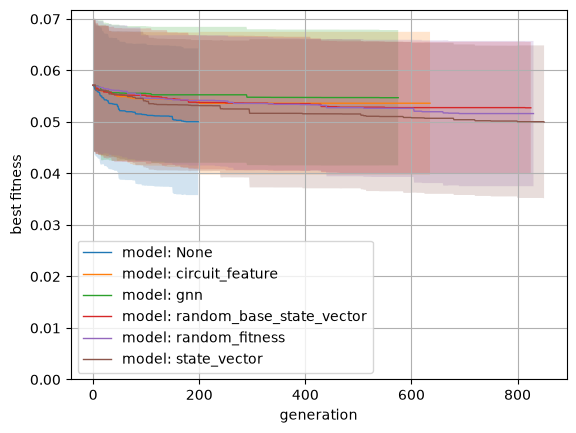

Fitness over explicit evaluations


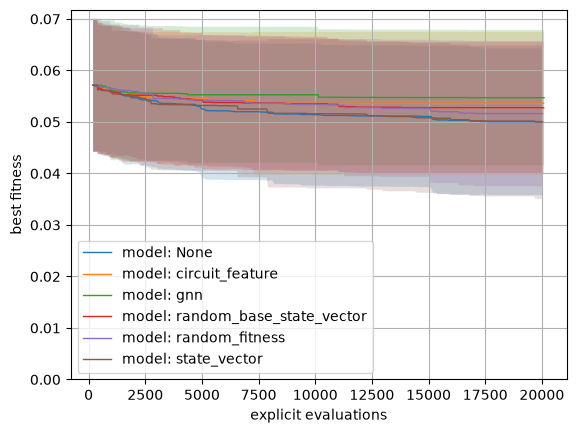

Fitness over time


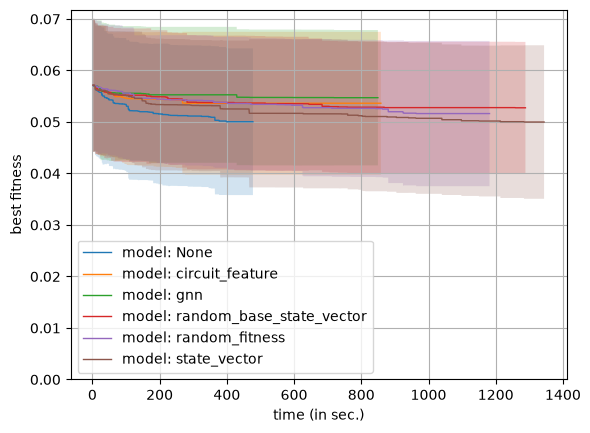

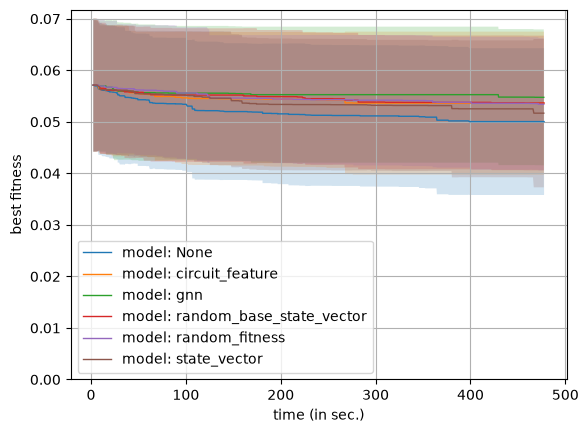

Detailed per seed results:
	'model: None' outperformed on 0/5 seeds (0%), tied on 5/5 (100%)
	'model: circuit_feature' outperformed on 0/5 seeds (0%), tied on 0/5 (0%)
	'model: gnn' outperformed on 0/5 seeds (0%), tied on 0/5 (0%)
	'model: random_base_state_vector' outperformed on 0/5 seeds (0%), tied on 0/5 (0%)
	'model: random_fitness' outperformed on 0/5 seeds (0%), tied on 0/5 (0%)
	'model: state_vector' outperformed on 2/5 seeds (40%), tied on 0/5 (0%)

Successful runs per experiment:
	'model: None' found a good approximation in 0/5 runs (0%)
	'model: circuit_feature' found a good approximation in 0/5 runs (0%)
	'model: gnn' found a good approximation in 0/5 runs (0%)
	'model: random_base_state_vector' found a good approximation in 0/5 runs (0%)
	'model: random_fitness' found a good approximation in 0/5 runs (0%)
	'model: state_vector' found a good approximation in 0/5 runs (0%)

Rank correlations


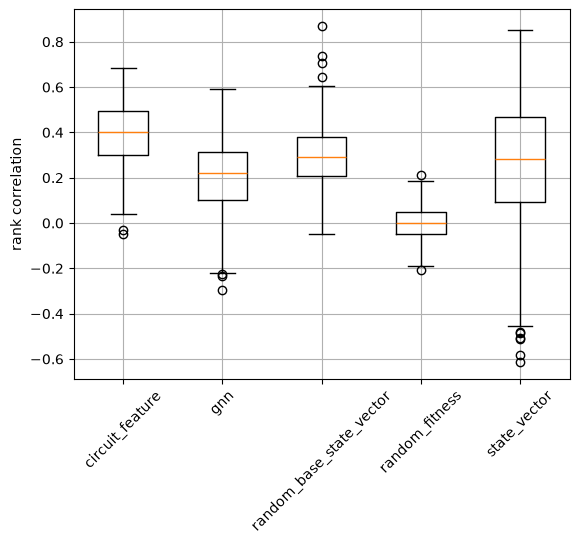

Rank correlations per generation


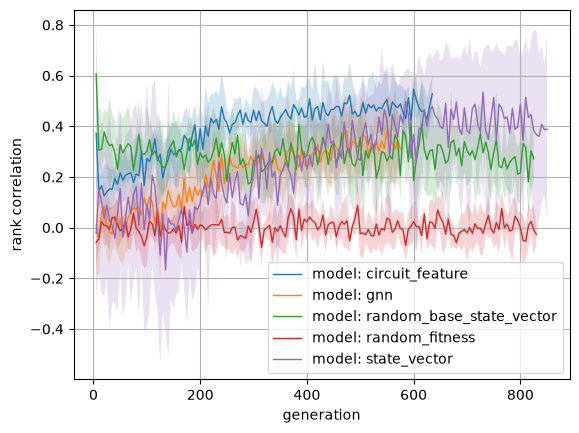

Fitness mse values


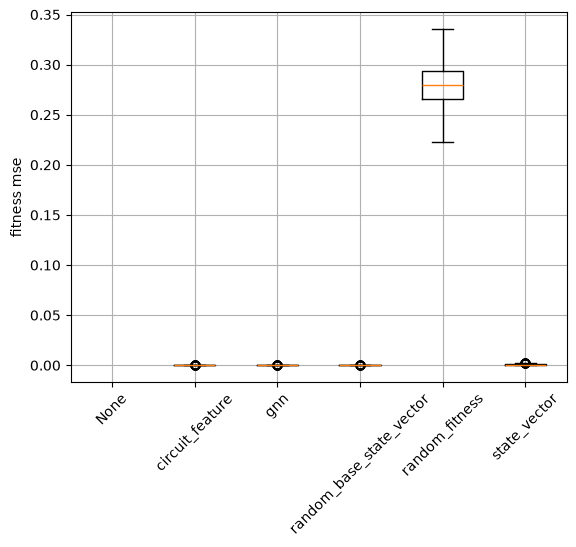

Population diversity


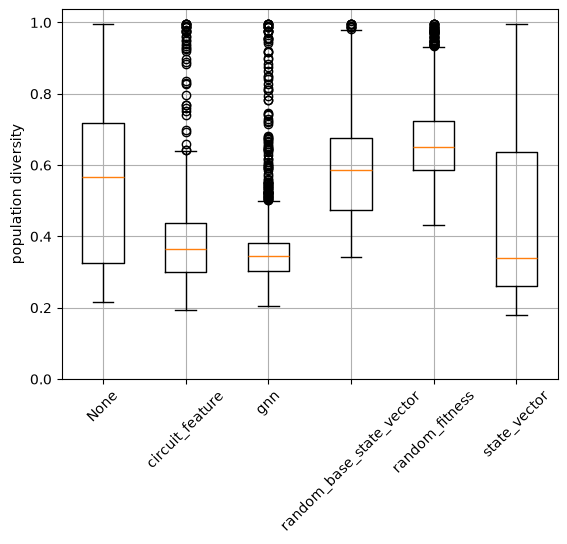

Survivorship rate since last exact evaluation


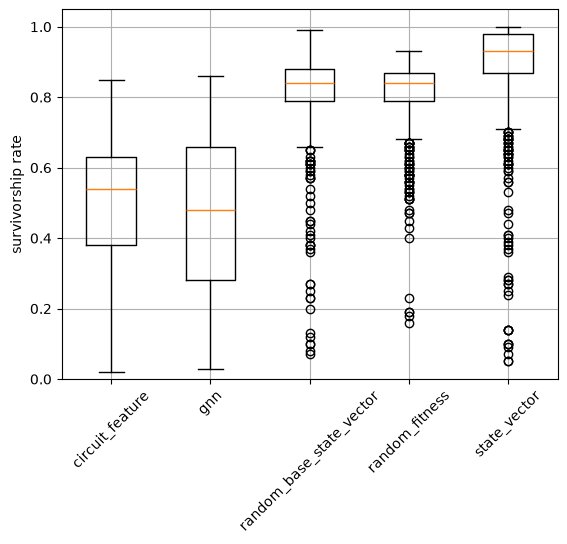


Per seed results of model: None


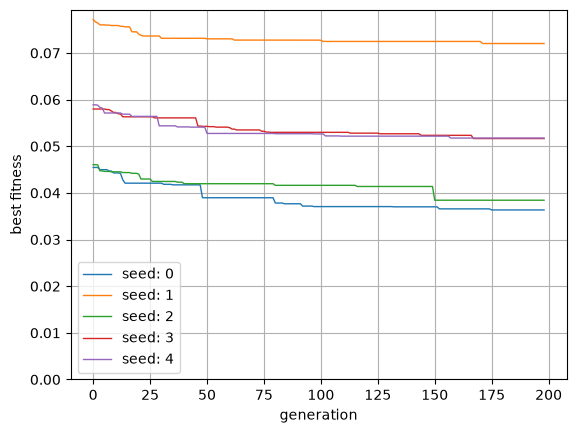


Per seed results of model: circuit_feature


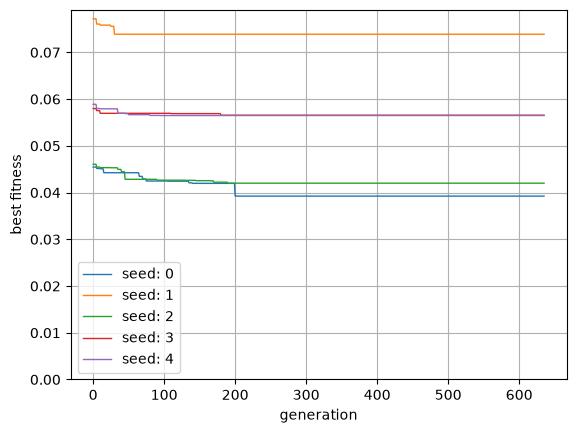


Per seed results of model: gnn


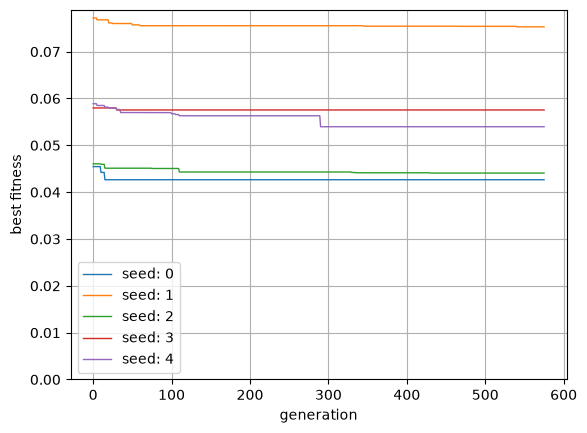


Per seed results of model: random_base_state_vector


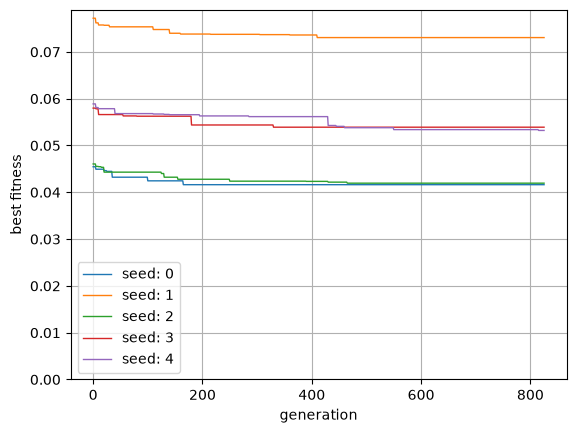


Per seed results of model: random_fitness


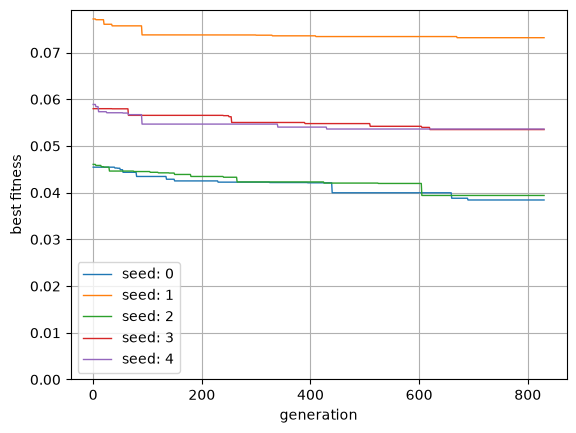


Per seed results of model: state_vector


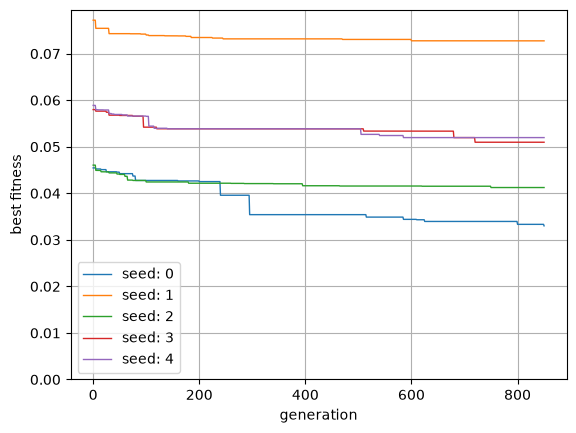

<Figure size 640x480 with 0 Axes>

In [ ]:

qubit_nums = [experiment.qubit_num for experiment in experiments]
qubit_nums = sorted(list(set(qubit_nums)))

gate_counts = [experiment.gate_count for experiment in experiments]
gate_counts = sorted(list(set(gate_counts)))

evaluate_every_values = [experiment.evaluate_every for experiment in experiments]
evaluate_every_values = sorted(list(set(evaluate_every_values)))

for qubit_num in qubit_nums:
    for gate_count in gate_counts:

        for evaluate_every in evaluate_every_values:

            rel_experiments = filter_experiments(experiments, filter_params={
                "qubit_num": qubit_num,
                "gate_count": gate_count,
                "evaluate_every": evaluate_every
            })

            if len(rel_experiments) == 0:
                continue

            sort_by_model(rel_experiments)

            labels = [
                f"model: {experiment.model}" for experiment in rel_experiments]

            print()
            printb("=" * 80)
            printb(
                f"Experiment results for {qubit_num} qubits and {gate_count} gates with evaluation every {evaluate_every}. generation")
            printb("=" * 80)

            print("Seed count per setup: ")
            print([(experiment.model, len(experiment.seeds))
                for experiment in rel_experiments])

            print("Fitness per generation")
            plot_fitness_per_generation(rel_experiments, labels=labels,
                                        target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_fitness_per_generation.png")

            print("Fitness over explicit evaluations")
            plot_fitness_per_evaluations(
                rel_experiments, labels=labels, target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_fitness_over_evaluations.png")

            print("Fitness over time")
            plot_fitness_per_timestamp(rel_experiments, labels=labels,
                                    target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_fitness_over_time.png")
            plot_fitness_per_timestamp(rel_experiments, labels=labels,
                                    target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_fitness_over_time_cutoff.png", 
                                    max_cum_duration=max(rel_experiments[0].data_by_timestamp["cum_duration"]))

            print_victories_over_baseline(
                rel_experiments, labels, baseline=rel_experiments[0])
            print_succesfull_runs(rel_experiments, labels)

            print("Rank correlations")
            plot_rank_correlations(rel_experiments[1:], labels=labels[1:],
                                target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_rank_correlations.png")

            print("Rank correlations per generation")
            plot_rank_correlation_per_generation(
                rel_experiments[1:], labels=labels[1:], target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_rank_correlation_per_generation.png"
            )

            print("Fitness mse values")
            plot_fitness_mse_scores(rel_experiments, labels=labels, target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_fitness_mse_scores.png")

            # plot_mse_scores_per_generation(
            #     rel_experiments[1:], labels=labels[1:], max_generations=1500
            # )

            # print("Survival rate per generation")
            # plot_survival_rate_per_generation(
            #     rel_experiments, labels=labels, target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_survival_rate.png", plot_std=False)


            print("Population diversity")
            plot_population_diversity(
                rel_experiments, labels=labels, target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_population_diversity.png"
            )

            # print("Population diversity per generation")
            # plot_population_diversity_per_generation(
            #     rel_experiments, labels=labels, target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_population_diversity_per_generation.png", plot_std=False
            # )

            # print("Durations per generation")
            # plot_duration(rel_experiments, labels=labels, target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_duration.png")

            # plot_duration_stacked(rel_experiments, labels=labels, , relative=True)
            # print("Duration per generation of all generations")
            # plot_duration_stacked(rel_experiments, labels=labels, relative=False, target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_duration_stacked_all_generations.png")
            # print("Duration per generation of evaluated generations")
            # plot_duration_stacked(rel_experiments, labels=labels, generations="evaluated", relative=False, target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_duration_stacked_evaluated_generations.png")
            # print("Duration per generation of not evaluated generations")
            # plot_duration_stacked(rel_experiments, labels=labels, generations="not_evaluated", relative=False, target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_duration_stacked_not_evaluated_generations.png")

            # print_time_distribution(rel_experiments, labels=labels)

            # print("Max memory per generation")
            # plot_max_memory_per_generation(
            #     rel_experiments, labels=labels, target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_max_memory_per_generation.png", max_generations=500
            # )
            # print_memory_distribution(rel_experiments, labels=labels)

            # print("Max memory per generation of evaluated generations")
            # plot_memory(rel_experiments, labels, generations="evaluated", target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_memory_grouped_evaluated_generations.png")
            # print("Max memory per generation of not evaluated generations")
            # plot_memory(rel_experiments, labels, generations="not_evaluated", target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_memory_grouped_not_evaluated_generations.png")

            for experiment, label in zip(rel_experiments, labels):
                print(f"\nPer seed results of {label}")
                plot_fitness_per_seed(
                    experiment=experiment, target_path=f"results/{qubit_num}q{gate_count}g{evaluate_every}e_{label}_fitness_per_seed.png")